# Data Cleaning & Data Quality Assessment

MISSING VALUE ANALYSIS

FEAR & GREED DATASET - MISSING VALUES


,Missing Count,Missing Percentage (%)
timestamp,0,0.0
value,0,0.0
classification,0,0.0
date,0,0.0
Merge_Date,0,0.0




HISTORICAL DATASET - MISSING VALUES


,Missing Count,Missing Percentage (%)
Account,0,0.0
Coin,0,0.0
Execution Price,0,0.0
Size Tokens,0,0.0
Size USD,0,0.0
Side,0,0.0
Timestamp IST,0,0.0
Start Position,0,0.0
Direction,0,0.0
Closed PnL,0,0.0




MERGED DATASET - MISSING VALUES


,Missing Count,Missing Percentage (%)
classification,6,0.002841
value,6,0.002841
Account,0,0.000000
Execution Price,0,0.000000
Coin,0,0.000000
Size Tokens,0,0.000000
Size USD,0,0.000000
Start Position,0,0.000000
Direction,0,0.000000
Side,0,0.000000




UNMATCHED SENTIMENT ROWS
Number of unmatched rows: 6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Merge_Date,value,classification
727,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.8330,10000.00,28330.00,BUY,2024-10-26 04:44:00,-32797.51,Close Short,11655.000000,0x4da9426d2bf6ec027d8404152f9bad02010700c745eb...,40671411386,False,2.719680,8.350000e+13,1.730000e+12,2024-10-26,NaN,NaN
728,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.7110,10797.51,29272.05,BUY,2024-10-26 04:52:00,-22797.51,Close Short,13901.794130,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671438761,False,2.810115,3.230000e+14,1.730000e+12,2024-10-26,NaN,NaN
729,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,6908.33,17884.98,BUY,2024-10-26 04:52:00,-12000.00,Close Short,9737.981968,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,1.716957,1.070000e+15,1.730000e+12,2024-10-26,NaN,NaN
730,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,529.39,1370.54,BUY,2024-10-26 04:52:00,-5091.67,Close Short,746.228144,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,0.131570,8.770000e+14,1.730000e+12,2024-10-26,NaN,NaN
731,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,38.65,100.06,BUY,2024-10-26 04:52:00,-4562.28,Close Short,54.481040,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,0.009605,9.820000e+14,1.730000e+12,2024-10-26,NaN,NaN
732,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,4523.63,11711.23,BUY,2024-10-26 04:53:00,-4523.63,Close Short,6376.508848,0x39ce7efcc1773fd0eec704152fbcb4010100c8beadd4...,40671466136,False,1.124277,9.360000e+14,1.730000e+12,2024-10-26,NaN,NaN


No missing values found in Fear & Greed Dataset Missing Values
No missing values found in Historical Dataset Missing Values


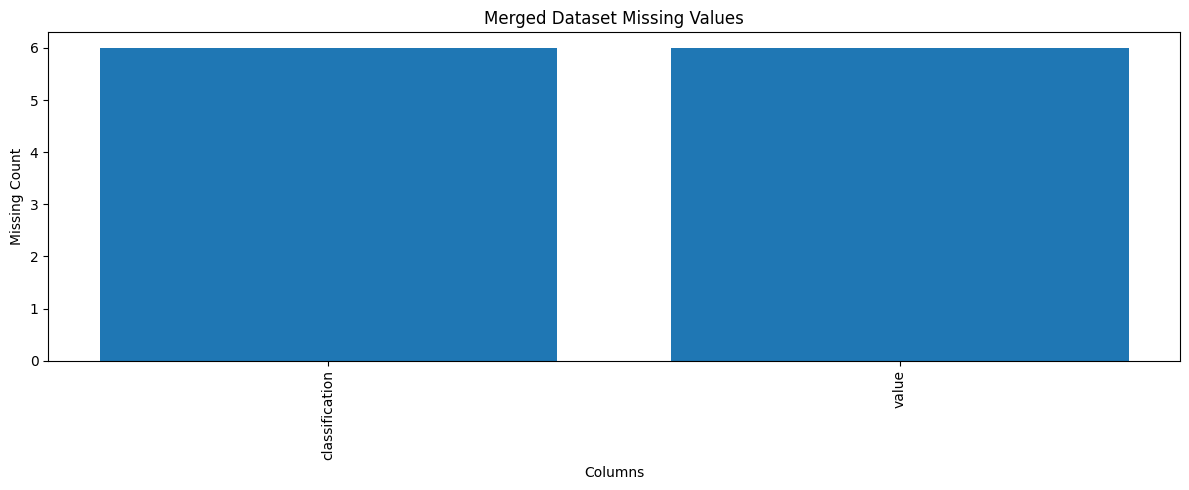


Processed datasets saved successfully.
Folder: /content/drive/MyDrive/Primetrade_Assignment/phase2


In [1]:
# ============================================================
# PHASE 2 - STEP 1: MISSING VALUE ANALYSIS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


def load_datasets(fear_greed_path, historical_data_path):
    """
    Load datasets.
    """
    fear_greed_df = pd.read_csv(fear_greed_path)
    historical_df = pd.read_csv(historical_data_path)

    return fear_greed_df, historical_df


def preprocess_datasets(fear_greed_df, historical_df):
    """
    Convert date columns and create merge key.
    """
    fear_greed_df = fear_greed_df.copy()
    historical_df = historical_df.copy()

    fear_greed_df["date"] = pd.to_datetime(
        fear_greed_df["date"]
    )

    historical_df["Timestamp IST"] = pd.to_datetime(
        historical_df["Timestamp IST"],
        dayfirst=True,
        errors="coerce"
    )

    fear_greed_df["Merge_Date"] = (
        fear_greed_df["date"].dt.date
    )

    historical_df["Merge_Date"] = (
        historical_df["Timestamp IST"].dt.date
    )

    return fear_greed_df, historical_df


def create_merged_dataset(
    fear_greed_df,
    historical_df
):
    """
    Merge datasets using date.
    """
    merged_df = historical_df.merge(
        fear_greed_df[
            [
                "Merge_Date",
                "value",
                "classification"
            ]
        ],
        on="Merge_Date",
        how="left"
    )

    return merged_df


def get_missing_value_summary(dataframe):
    """
    Generate missing value summary.
    """
    missing_count = dataframe.isnull().sum()

    missing_percentage = (
        dataframe.isnull().sum()
        / len(dataframe)
    ) * 100

    summary = pd.DataFrame({
        "Missing Count": missing_count,
        "Missing Percentage (%)": missing_percentage
    })

    summary = summary.sort_values(
        by="Missing Count",
        ascending=False
    )

    return summary


def get_rows_with_missing_sentiment(
    merged_df
):
    """
    Extract rows where sentiment was not matched.
    """
    unmatched_rows = merged_df[
        merged_df["classification"].isnull()
    ]

    return unmatched_rows


def plot_missing_values(
    missing_summary,
    title
):
    """
    Plot missing values.
    """
    plot_df = missing_summary[
        missing_summary["Missing Count"] > 0
    ]

    if len(plot_df) == 0:
        print(f"No missing values found in {title}")
        return

    plt.figure(figsize=(12, 5))

    plt.bar(
        plot_df.index,
        plot_df["Missing Count"]
    )

    plt.title(title)
    plt.xlabel("Columns")
    plt.ylabel("Missing Count")

    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()


def create_phase2_folder(folder_path):
    """
    Create phase2 folder if not exists.
    """
    os.makedirs(
        folder_path,
        exist_ok=True
    )


def save_datasets(
    fear_greed_df,
    historical_df,
    merged_df,
    folder_path
):
    """
    Save datasets.
    """
    fear_greed_df.to_csv(
        f"{folder_path}/fear_greed_processed.csv",
        index=False
    )

    historical_df.to_csv(
        f"{folder_path}/historical_processed.csv",
        index=False
    )

    merged_df.to_csv(
        f"{folder_path}/merged_dataset.csv",
        index=False
    )


# ============================================================
# MAIN PROGRAM
# ============================================================

fear_greed_path = (
    "/content/drive/MyDrive/"
    "Primetrade_Assignment/fear_greed_index.csv"
)

historical_data_path = (
    "/content/drive/MyDrive/"
    "Primetrade_Assignment/historical_data.csv"
)

phase2_folder = (
    "/content/drive/MyDrive/"
    "Primetrade_Assignment/phase2"
)

# Load
fear_greed_df, historical_df = load_datasets(
    fear_greed_path,
    historical_data_path
)

# Preprocess
fear_greed_df, historical_df = preprocess_datasets(
    fear_greed_df,
    historical_df
)

# Merge
merged_df = create_merged_dataset(
    fear_greed_df,
    historical_df
)

# Missing value summaries
fear_greed_missing = get_missing_value_summary(
    fear_greed_df
)

historical_missing = get_missing_value_summary(
    historical_df
)

merged_missing = get_missing_value_summary(
    merged_df
)

# Missing sentiment rows
unmatched_rows = get_rows_with_missing_sentiment(
    merged_df
)

# ============================================================
# OUTPUTS
# ============================================================

print("=" * 70)
print("FEAR & GREED DATASET - MISSING VALUES")
print("=" * 70)

display(fear_greed_missing)

print("\n")

print("=" * 70)
print("HISTORICAL DATASET - MISSING VALUES")
print("=" * 70)

display(historical_missing)

print("\n")

print("=" * 70)
print("MERGED DATASET - MISSING VALUES")
print("=" * 70)

display(merged_missing)

print("\n")

print("=" * 70)
print("UNMATCHED SENTIMENT ROWS")
print("=" * 70)

print("Number of unmatched rows:",
      len(unmatched_rows))

display(unmatched_rows)

# ============================================================
# PLOTS
# ============================================================

plot_missing_values(
    fear_greed_missing,
    "Fear & Greed Dataset Missing Values"
)

plot_missing_values(
    historical_missing,
    "Historical Dataset Missing Values"
)

plot_missing_values(
    merged_missing,
    "Merged Dataset Missing Values"
)

# ============================================================
# SAVE FILES
# ============================================================

create_phase2_folder(
    phase2_folder
)

save_datasets(
    fear_greed_df,
    historical_df,
    merged_df,
    phase2_folder
)

print("\nProcessed datasets saved successfully.")
print("Folder:", phase2_folder)

Duplicate Analysis

FEAR & GREED DUPLICATE ANALYSIS
Total Rows: 2644
Duplicate Rows: 0
Duplicate Percentage (%): 0.0

Duplicate Sentiment Records:


,timestamp,value,classification,date,Merge_Date




HISTORICAL DATA DUPLICATE ANALYSIS
Total Rows: 211224
Duplicate Rows: 0
Duplicate Percentage (%): 0.0

Duplicate Trade Records:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Merge_Date




MERGED DATA DUPLICATE ANALYSIS
Total Rows: 211224
Duplicate Rows: 0
Duplicate Percentage (%): 0.0

Duplicate Merged Records:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Merge_Date,value,classification




DUPLICATE SENTIMENT DATES
Number of duplicate dates: 0


,timestamp,value,classification,date,Merge_Date




DUPLICATE TRADE IDs
Number of duplicate Trade IDs: 2349


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Merge_Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9900,1.41,11.27,BUY,2024-12-02 22:50:00,1298.215466,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.000493,7.330000e+14,1.730000e+12,2024-12-02
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9934,144.09,1151.77,BUY,2024-12-02 22:50:00,1299.624972,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,9.060000e+14,1.730000e+12,2024-12-02
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,34.00,272.00,BUY,2024-12-02 22:50:00,1443.664541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.011900,3.960000e+14,1.730000e+12,2024-12-02
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,46.00,368.00,BUY,2024-12-02 22:50:00,1477.652641,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.016100,9.460000e+14,1.730000e+12,2024-12-02
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,12.50,100.00,BUY,2024-12-02 22:50:00,1523.636541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.004375,3.470000e+13,1.730000e+12,2024-12-02


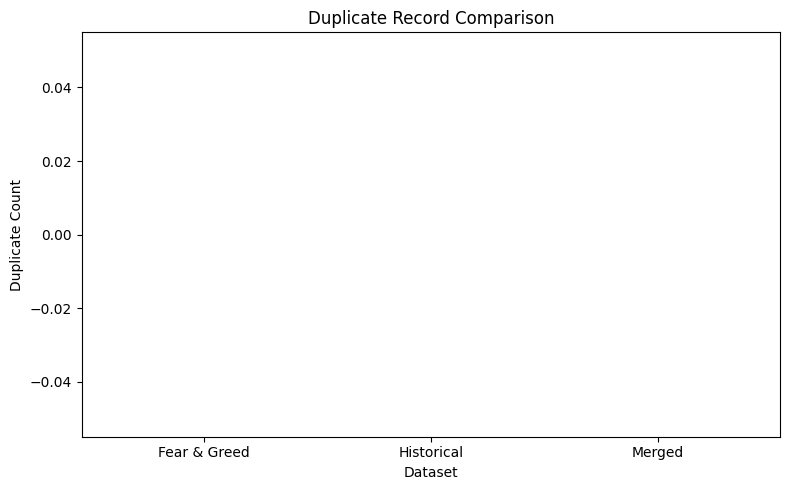


Duplicate-free datasets saved successfully.


In [2]:
# ============================================================
# PHASE 2 - STEP 2: DUPLICATE ANALYSIS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


def get_duplicate_summary(dataframe):
    """
    Calculate duplicate statistics.
    """

    total_rows = len(dataframe)

    duplicate_rows = dataframe.duplicated().sum()

    duplicate_percentage = (
        duplicate_rows / total_rows
    ) * 100

    summary = {
        "Total Rows": total_rows,
        "Duplicate Rows": duplicate_rows,
        "Duplicate Percentage (%)": duplicate_percentage
    }

    return summary


def get_duplicate_records(dataframe):
    """
    Extract duplicate records.
    """

    duplicate_records = dataframe[
        dataframe.duplicated(
            keep=False
        )
    ]

    return duplicate_records


def get_duplicate_dates_fear_greed(
    dataframe
):
    """
    Check duplicate sentiment dates.
    """

    duplicate_dates = dataframe[
        dataframe.duplicated(
            subset=["Merge_Date"],
            keep=False
        )
    ]

    return duplicate_dates


def get_duplicate_trade_ids(
    dataframe
):
    """
    Check duplicate trade IDs.
    """

    duplicate_trade_ids = dataframe[
        dataframe.duplicated(
            subset=["Trade ID"],
            keep=False
        )
    ]

    return duplicate_trade_ids


def plot_duplicate_comparison(
    fear_summary,
    historical_summary,
    merged_summary
):
    """
    Plot duplicate comparison.
    """

    dataset_names = [
        "Fear & Greed",
        "Historical",
        "Merged"
    ]

    duplicate_counts = [
        fear_summary["Duplicate Rows"],
        historical_summary["Duplicate Rows"],
        merged_summary["Duplicate Rows"]
    ]

    plt.figure(figsize=(8, 5))

    plt.bar(
        dataset_names,
        duplicate_counts
    )

    plt.title(
        "Duplicate Record Comparison"
    )

    plt.xlabel(
        "Dataset"
    )

    plt.ylabel(
        "Duplicate Count"
    )

    plt.tight_layout()
    plt.show()


def remove_duplicates(dataframe):
    """
    Remove duplicate rows.
    """

    cleaned_dataframe = (
        dataframe
        .drop_duplicates()
        .copy()
    )

    return cleaned_dataframe


def save_cleaned_datasets(
    fear_greed_df,
    historical_df,
    merged_df,
    folder_path
):
    """
    Save duplicate-free datasets.
    """

    fear_greed_df.to_csv(
        f"{folder_path}/fear_greed_no_duplicates.csv",
        index=False
    )

    historical_df.to_csv(
        f"{folder_path}/historical_no_duplicates.csv",
        index=False
    )

    merged_df.to_csv(
        f"{folder_path}/merged_no_duplicates.csv",
        index=False
    )


# ============================================================
# MAIN PROGRAM
# ============================================================

# fear_greed_df
# historical_df
# merged_df

fear_duplicate_summary = (
    get_duplicate_summary(
        fear_greed_df
    )
)

historical_duplicate_summary = (
    get_duplicate_summary(
        historical_df
    )
)

merged_duplicate_summary = (
    get_duplicate_summary(
        merged_df
    )
)

fear_duplicate_records = (
    get_duplicate_records(
        fear_greed_df
    )
)

historical_duplicate_records = (
    get_duplicate_records(
        historical_df
    )
)

merged_duplicate_records = (
    get_duplicate_records(
        merged_df
    )
)

duplicate_dates = (
    get_duplicate_dates_fear_greed(
        fear_greed_df
    )
)

duplicate_trade_ids = (
    get_duplicate_trade_ids(
        historical_df
    )
)

# ============================================================
# OUTPUTS
# ============================================================

print("=" * 70)
print("FEAR & GREED DUPLICATE ANALYSIS")
print("=" * 70)

for key, value in fear_duplicate_summary.items():
    print(f"{key}: {value}")

print("\nDuplicate Sentiment Records:")
display(
    fear_duplicate_records.head(20)
)

print("\n")

print("=" * 70)
print("HISTORICAL DATA DUPLICATE ANALYSIS")
print("=" * 70)

for key, value in historical_duplicate_summary.items():
    print(f"{key}: {value}")

print("\nDuplicate Trade Records:")
display(
    historical_duplicate_records.head(20)
)

print("\n")

print("=" * 70)
print("MERGED DATA DUPLICATE ANALYSIS")
print("=" * 70)

for key, value in merged_duplicate_summary.items():
    print(f"{key}: {value}")

print("\nDuplicate Merged Records:")
display(
    merged_duplicate_records.head(20)
)

print("\n")

print("=" * 70)
print("DUPLICATE SENTIMENT DATES")
print("=" * 70)

print(
    "Number of duplicate dates:",
    duplicate_dates["Merge_Date"].nunique()
)

display(
    duplicate_dates.head(20)
)

print("\n")

print("=" * 70)
print("DUPLICATE TRADE IDs")
print("=" * 70)

print(
    "Number of duplicate Trade IDs:",
    duplicate_trade_ids["Trade ID"].nunique()
)

display(
    duplicate_trade_ids.head(20)
)

# ============================================================
# PLOT
# ============================================================

plot_duplicate_comparison(
    fear_duplicate_summary,
    historical_duplicate_summary,
    merged_duplicate_summary
)

# ============================================================
# SAVE CLEANED DATA
# ============================================================

fear_greed_clean = remove_duplicates(
    fear_greed_df
)

historical_clean = remove_duplicates(
    historical_df
)

merged_clean = remove_duplicates(
    merged_df
)

save_cleaned_datasets(
    fear_greed_clean,
    historical_clean,
    merged_clean,
    phase2_folder
)

print("\nDuplicate-free datasets saved successfully.")

Data Type Validation & Consistency Checks

FEAR & GREED DATA TYPES


,Column,Data Type
timestamp,timestamp,int64
value,value,int64
classification,classification,object
date,date,datetime64[ns]
Merge_Date,Merge_Date,object



Validation Results
value_is_numeric: True
date_is_datetime: True
invalid_sentiment_scores: 0


HISTORICAL DATA TYPES


,Column,Data Type
Account,Account,object
Coin,Coin,object
Execution Price,Execution Price,float64
Size Tokens,Size Tokens,float64
Size USD,Size USD,float64
Side,Side,object
Timestamp IST,Timestamp IST,datetime64[ns]
Start Position,Start Position,float64
Direction,Direction,object
Closed PnL,Closed PnL,float64



Validation Results
closed_pnl_is_numeric: True
size_usd_is_numeric: True
execution_price_is_numeric: True
timestamp_is_datetime: True


CONSISTENCY CHECKS
Negative Size USD: 0
Negative Execution Price: 0
Zero Execution Price: 0
Missing Timestamp: 0


NUMERIC FEATURE SUMMARY


,Execution Price,Size USD,Closed PnL
count,211224.000000,2.112240e+05,211224.000000
mean,11414.723350,5.639451e+03,48.749001
std,29447.654868,3.657514e+04,919.164828
min,0.000005,0.000000e+00,-117990.104100
25%,4.854700,1.937900e+02,0.000000
50%,18.280000,5.970450e+02,0.000000
75%,101.580000,2.058960e+03,5.792797
max,109004.000000,3.921431e+06,135329.090100


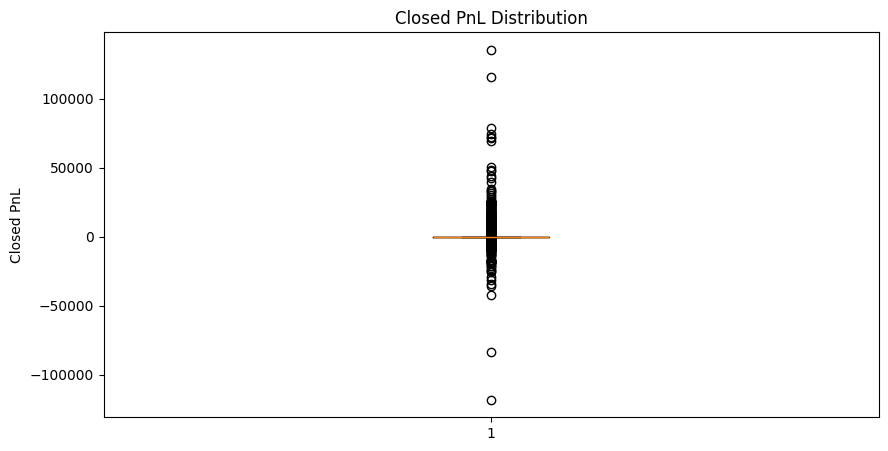

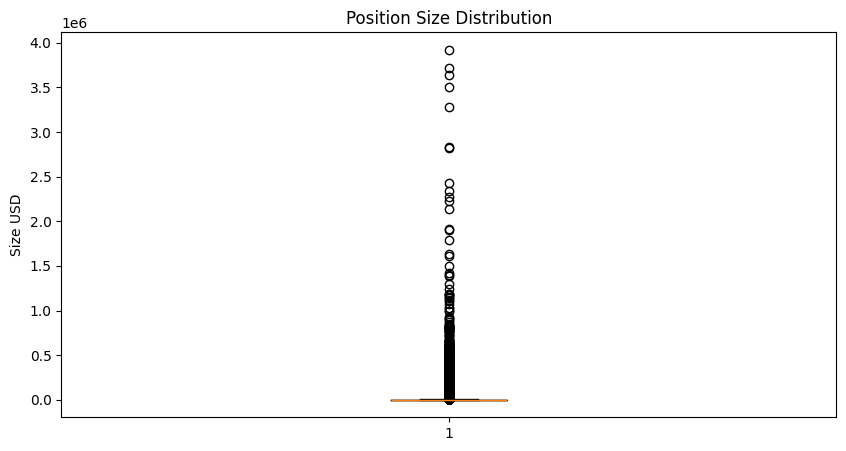


Validated datasets saved successfully.


In [3]:
# ============================================================
# PHASE 2 - STEP 3:
# DATA TYPE VALIDATION & CONSISTENCY CHECKS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


def get_dtype_summary(dataframe):
    """
    Return column data types.
    """

    dtype_summary = pd.DataFrame(
        {
            "Column": dataframe.columns,
            "Data Type": dataframe.dtypes.astype(str)
        }
    )

    return dtype_summary


def validate_fear_greed_dataset(
    dataframe
):
    """
    Validate Fear & Greed dataset.
    """

    validation_results = {
        "value_is_numeric":
            pd.api.types.is_numeric_dtype(
                dataframe["value"]
            ),

        "date_is_datetime":
            pd.api.types.is_datetime64_any_dtype(
                dataframe["date"]
            ),

        "invalid_sentiment_scores":
            (
                (dataframe["value"] < 0) |
                (dataframe["value"] > 100)
            ).sum()
    }

    return validation_results


def validate_historical_dataset(
    dataframe
):
    """
    Validate trading dataset.
    """

    validation_results = {
        "closed_pnl_is_numeric":
            pd.api.types.is_numeric_dtype(
                dataframe["Closed PnL"]
            ),

        "size_usd_is_numeric":
            pd.api.types.is_numeric_dtype(
                dataframe["Size USD"]
            ),

        "execution_price_is_numeric":
            pd.api.types.is_numeric_dtype(
                dataframe["Execution Price"]
            ),

        "timestamp_is_datetime":
            pd.api.types.is_datetime64_any_dtype(
                dataframe["Timestamp IST"]
            )
    }

    return validation_results


def get_consistency_summary(
    dataframe
):
    """
    Check for impossible values.
    """

    consistency_results = {
        "Negative Size USD":
            (
                dataframe["Size USD"] < 0
            ).sum(),

        "Negative Execution Price":
            (
                dataframe["Execution Price"] < 0
            ).sum(),

        "Zero Execution Price":
            (
                dataframe["Execution Price"] == 0
            ).sum(),

        "Missing Timestamp":
            dataframe["Timestamp IST"]
            .isnull()
            .sum()
    }

    return consistency_results


def get_numeric_summary(
    dataframe
):
    """
    Summary statistics for key features.
    """

    numeric_summary = dataframe[
        [
            "Execution Price",
            "Size USD",
            "Closed PnL"
        ]
    ].describe()

    return numeric_summary


def plot_closed_pnl_boxplot(
    dataframe
):
    """
    Closed PnL boxplot.
    """

    plt.figure(figsize=(10, 5))

    plt.boxplot(
        dataframe["Closed PnL"]
    )

    plt.title(
        "Closed PnL Distribution"
    )

    plt.ylabel(
        "Closed PnL"
    )

    plt.show()


def plot_size_usd_boxplot(
    dataframe
):
    """
    Size USD boxplot.
    """

    plt.figure(figsize=(10, 5))

    plt.boxplot(
        dataframe["Size USD"]
    )

    plt.title(
        "Position Size Distribution"
    )

    plt.ylabel(
        "Size USD"
    )

    plt.show()


def save_validated_datasets(
    fear_greed_df,
    historical_df,
    merged_df,
    folder_path
):
    """
    Save validated datasets.
    """

    fear_greed_df.to_csv(
        f"{folder_path}/fear_greed_validated.csv",
        index=False
    )

    historical_df.to_csv(
        f"{folder_path}/historical_validated.csv",
        index=False
    )

    merged_df.to_csv(
        f"{folder_path}/merged_validated.csv",
        index=False
    )


# ============================================================
# MAIN PROGRAM
# ============================================================

fear_dtype_summary = (
    get_dtype_summary(
        fear_greed_df
    )
)

historical_dtype_summary = (
    get_dtype_summary(
        historical_df
    )
)

fear_validation = (
    validate_fear_greed_dataset(
        fear_greed_df
    )
)

historical_validation = (
    validate_historical_dataset(
        historical_df
    )
)

consistency_summary = (
    get_consistency_summary(
        historical_df
    )
)

numeric_summary = (
    get_numeric_summary(
        historical_df
    )
)

# ============================================================
# OUTPUTS
# ============================================================

print("=" * 70)
print("FEAR & GREED DATA TYPES")
print("=" * 70)

display(
    fear_dtype_summary
)

print("\nValidation Results")

for key, value in fear_validation.items():
    print(f"{key}: {value}")

print("\n")

print("=" * 70)
print("HISTORICAL DATA TYPES")
print("=" * 70)

display(
    historical_dtype_summary
)

print("\nValidation Results")

for key, value in historical_validation.items():
    print(f"{key}: {value}")

print("\n")

print("=" * 70)
print("CONSISTENCY CHECKS")
print("=" * 70)

for key, value in consistency_summary.items():
    print(f"{key}: {value}")

print("\n")

print("=" * 70)
print("NUMERIC FEATURE SUMMARY")
print("=" * 70)

display(
    numeric_summary
)

# ============================================================
# PLOTS
# ============================================================

plot_closed_pnl_boxplot(
    historical_df
)

plot_size_usd_boxplot(
    historical_df
)

# ============================================================
# SAVE FILES
# ============================================================

save_validated_datasets(
    fear_greed_df,
    historical_df,
    merged_df,
    phase2_folder
)

print(
    "\nValidated datasets saved successfully."
)

OUTLIER SUMMARY


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Total Records,Outliers,Outlier Percentage
0,Closed PnL,0.0000,5.792797,5.792797,-8.689195,14.481992,211224,48941,23.170189
1,Size USD,193.7900,2058.960000,1865.170000,-2603.965000,4856.715000,211224,32661,15.462732
2,Execution Price,4.8547,101.580000,96.725300,-140.233250,246.667950,211224,42187,19.972636




TOP 20 EXTREME PROFITS


,Account,Coin,Size USD,Closed PnL
18045,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,292870.12,135329.09010
17270,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,685200.00,115287.00000
18043,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,170279.86,78682.72032
210024,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,921670.14,74530.52371
18024,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,156635.06,72377.74821
16328,0x083384f897ee0f19899168e3b1bec365f52a9012,SOL,301855.74,71535.71674
71354,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,1120971.60,68959.00212
16377,0x083384f897ee0f19899168e3b1bec365f52a9012,SOL,175555.89,50379.05774
49084,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,DOGE,60179.92,48504.09555
17075,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,785654.97,47883.62595




TOP 20 EXTREME LOSSES


,Account,Coin,Size USD,Closed PnL
14682,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,814524.17,-117990.10410
118582,0x8170715b3b381dffb7062c0298972d4727a0a63b,TRUMP,214400.00,-83056.32000
118498,0x8170715b3b381dffb7062c0298972d4727a0a63b,TRUMP,115769.55,-41910.06915
210767,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,237538.13,-35681.74723
118487,0x8170715b3b381dffb7062c0298972d4727a0a63b,TRUMP,95737.60,-34338.53409
142241,0x39cef799f8b69da1995852eea189df24eb5cae3c,@107,80252.78,-31036.69194
3737,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,373314.16,-29370.11980
209185,0x271b280974205ca63b716753467d5a371de622ab,BTC,999998.56,-25818.75012
203858,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,BERA,107500.00,-24500.00000
118613,0x8170715b3b381dffb7062c0298972d4727a0a63b,TRUMP,60000.97,-24080.11492




TOP 20 LARGEST POSITIONS


,Account,Coin,Size USD,Closed PnL
9465,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,3921430.72,18713.889180
9541,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,3719140.94,0.000000
10063,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,3641180.84,18022.958400
4402,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,3509752.98,2147.115209
8547,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,3279596.70,10024.262050
7784,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,2834011.35,0.000000
10064,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,2825834.19,0.000000
9740,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,2423217.53,4899.613452
7897,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,2343571.55,0.000000
5429,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,2268415.35,19530.522500


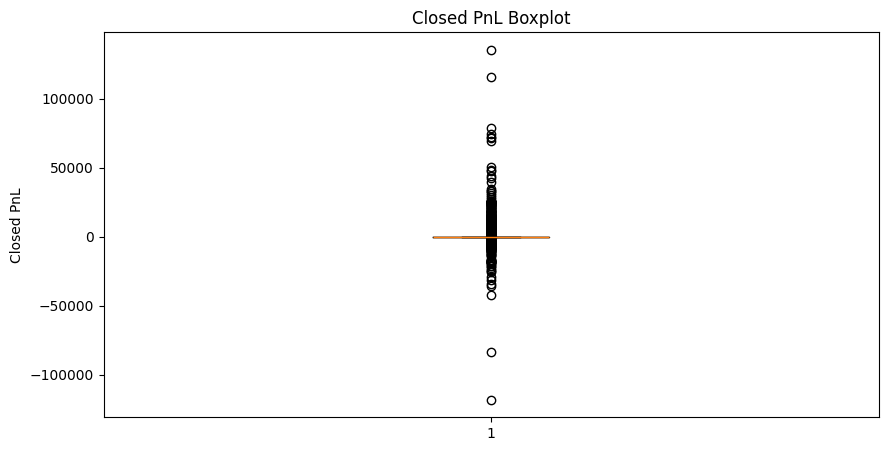

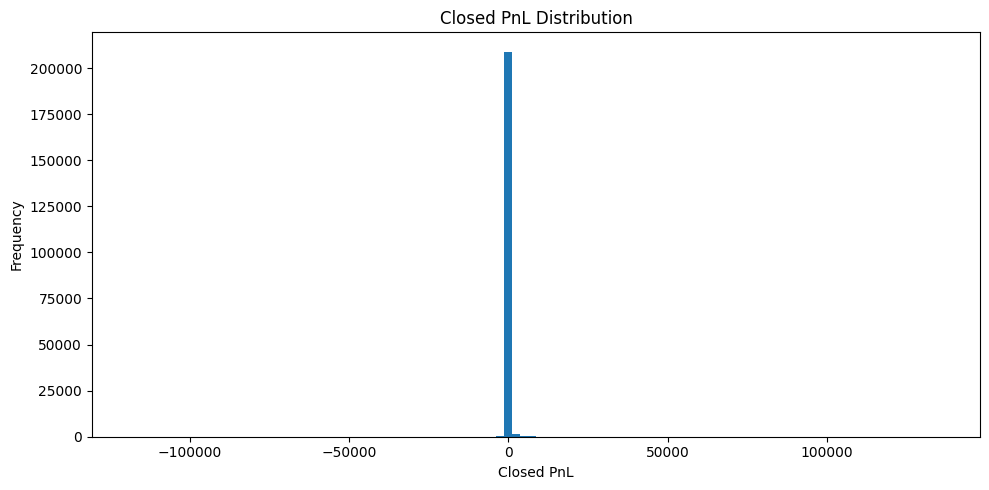

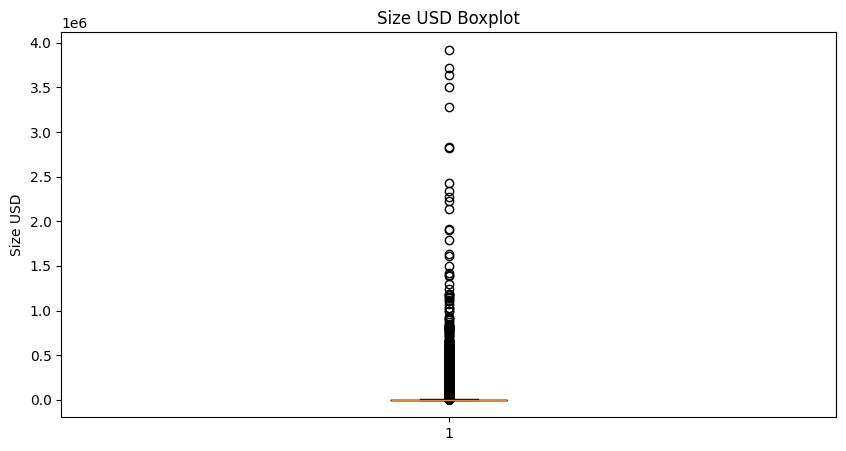

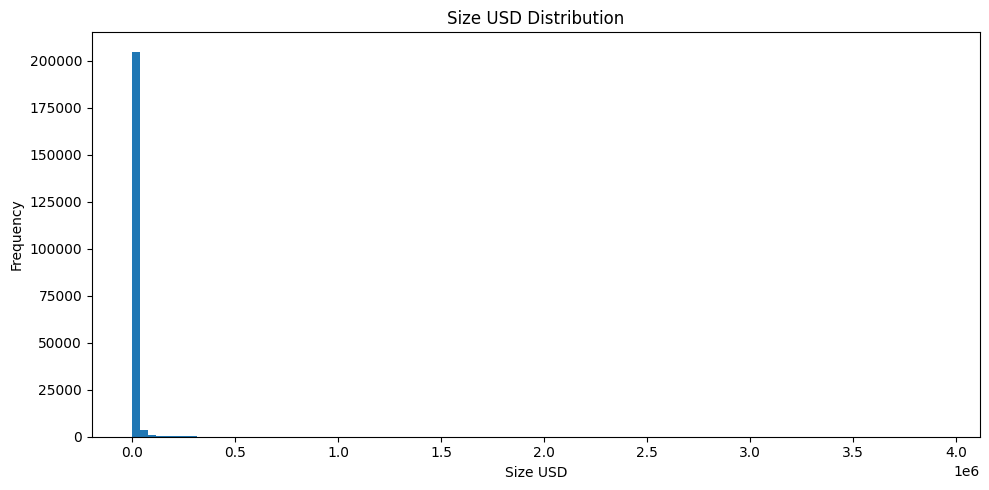

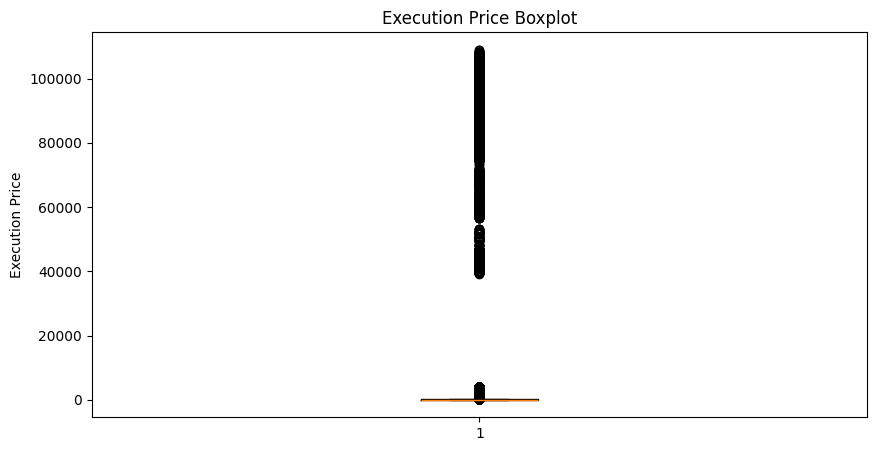

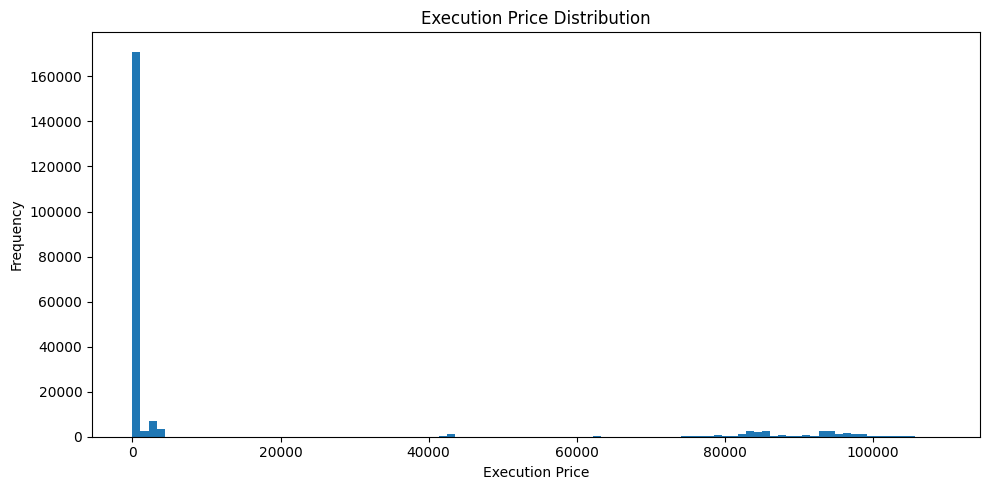

In [4]:
# ============================================================
# PHASE 2 - STEP 4: OUTLIER ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


def calculate_iqr_outliers(dataframe, column_name):
    """
    Detect outliers using IQR method.
    """

    q1 = dataframe[column_name].quantile(0.25)

    q3 = dataframe[column_name].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)

    upper_bound = q3 + (1.5 * iqr)

    outlier_dataframe = dataframe[
        (dataframe[column_name] < lower_bound)
        |
        (dataframe[column_name] > upper_bound)
    ]

    summary = {
        "Feature": column_name,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Total Records": len(dataframe),
        "Outliers": len(outlier_dataframe),
        "Outlier Percentage":
            (len(outlier_dataframe) / len(dataframe)) * 100
    }

    return summary, outlier_dataframe


def get_extreme_profits(
    dataframe,
    top_n=20
):
    """
    Top profitable trades.
    """

    return (
        dataframe
        .sort_values(
            by="Closed PnL",
            ascending=False
        )
        .head(top_n)
    )


def get_extreme_losses(
    dataframe,
    top_n=20
):
    """
    Top losing trades.
    """

    return (
        dataframe
        .sort_values(
            by="Closed PnL",
            ascending=True
        )
        .head(top_n)
    )


def get_largest_positions(
    dataframe,
    top_n=20
):
    """
    Largest positions.
    """

    return (
        dataframe
        .sort_values(
            by="Size USD",
            ascending=False
        )
        .head(top_n)
    )


def create_outlier_summary_table(
    summaries
):
    """
    Create summary table.
    """

    summary_table = pd.DataFrame(
        summaries
    )

    return summary_table


def plot_boxplot(
    dataframe,
    column_name
):
    """
    Boxplot.
    """

    plt.figure(figsize=(10, 5))

    plt.boxplot(
        dataframe[column_name]
    )

    plt.title(
        f"{column_name} Boxplot"
    )

    plt.ylabel(
        column_name
    )

    plt.show()


def plot_histogram(
    dataframe,
    column_name
):
    """
    Histogram.
    """

    plt.figure(figsize=(10, 5))

    plt.hist(
        dataframe[column_name],
        bins=100
    )

    plt.title(
        f"{column_name} Distribution"
    )

    plt.xlabel(
        column_name
    )

    plt.ylabel(
        "Frequency"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# MAIN PROGRAM
# ============================================================

pnl_summary, pnl_outliers = (
    calculate_iqr_outliers(
        historical_df,
        "Closed PnL"
    )
)

size_summary, size_outliers = (
    calculate_iqr_outliers(
        historical_df,
        "Size USD"
    )
)

price_summary, price_outliers = (
    calculate_iqr_outliers(
        historical_df,
        "Execution Price"
    )
)

outlier_summary_table = (
    create_outlier_summary_table(
        [
            pnl_summary,
            size_summary,
            price_summary
        ]
    )
)

extreme_profits = (
    get_extreme_profits(
        historical_df
    )
)

extreme_losses = (
    get_extreme_losses(
        historical_df
    )
)

largest_positions = (
    get_largest_positions(
        historical_df
    )
)

# ============================================================
# OUTPUTS
# ============================================================

print("=" * 70)
print("OUTLIER SUMMARY")
print("=" * 70)

display(
    outlier_summary_table
)

print("\n")

print("=" * 70)
print("TOP 20 EXTREME PROFITS")
print("=" * 70)

display(
    extreme_profits[
        [
            "Account",
            "Coin",
            "Size USD",
            "Closed PnL"
        ]
    ]
)

print("\n")

print("=" * 70)
print("TOP 20 EXTREME LOSSES")
print("=" * 70)

display(
    extreme_losses[
        [
            "Account",
            "Coin",
            "Size USD",
            "Closed PnL"
        ]
    ]
)

print("\n")

print("=" * 70)
print("TOP 20 LARGEST POSITIONS")
print("=" * 70)

display(
    largest_positions[
        [
            "Account",
            "Coin",
            "Size USD",
            "Closed PnL"
        ]
    ]
)

# ============================================================
# PLOTS
# ============================================================

plot_boxplot(
    historical_df,
    "Closed PnL"
)

plot_histogram(
    historical_df,
    "Closed PnL"
)

plot_boxplot(
    historical_df,
    "Size USD"
)

plot_histogram(
    historical_df,
    "Size USD"
)

plot_boxplot(
    historical_df,
    "Execution Price"
)

plot_histogram(
    historical_df,
    "Execution Price"
)

Merge Quality Validation

MERGE QUALITY SUMMARY
Total Trades: 211224
Matched Trades: 211218
Unmatched Trades: 6
Match Percentage: 99.99715941370299
Unmatched Percentage: 0.002840586297011703


DATE RANGE COMPARISON
Fear & Greed Start: 2018-02-01
Fear & Greed End: 2025-05-02
Trading Start: 2023-05-01
Trading End: 2025-05-01


UNMATCHED DATE ANALYSIS


,Date,Trade Count
0,2024-10-26,6



Missing Dates in Sentiment Dataset:
2024-10-26


UNMATCHED ROWS


,Account,Coin,Timestamp IST,Merge_Date,Closed PnL
727,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2024-10-26 04:44:00,2024-10-26,11655.000000
728,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2024-10-26 04:52:00,2024-10-26,13901.794130
729,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2024-10-26 04:52:00,2024-10-26,9737.981968
730,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2024-10-26 04:52:00,2024-10-26,746.228144
731,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2024-10-26 04:52:00,2024-10-26,54.481040
732,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2024-10-26 04:53:00,2024-10-26,6376.508848


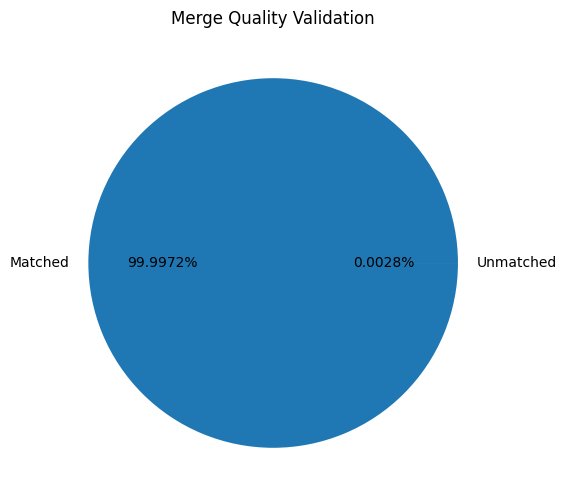


Unmatched rows saved successfully.


In [5]:
# ============================================================
# PHASE 2 - STEP 5: MERGE QUALITY VALIDATION
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


def get_unmatched_rows(dataframe):
    """
    Extract rows without sentiment labels.
    """

    unmatched_rows = dataframe[
        dataframe["classification"].isna()
    ].copy()

    return unmatched_rows


def get_merge_quality_summary(dataframe):
    """
    Calculate merge quality statistics.
    """

    total_rows = len(dataframe)

    matched_rows = (
        dataframe["classification"]
        .notna()
        .sum()
    )

    unmatched_rows = (
        dataframe["classification"]
        .isna()
        .sum()
    )

    summary = {
        "Total Trades": total_rows,
        "Matched Trades": matched_rows,
        "Unmatched Trades": unmatched_rows,
        "Match Percentage":
            (matched_rows / total_rows) * 100,
        "Unmatched Percentage":
            (unmatched_rows / total_rows) * 100
    }

    return summary


def get_unmatched_date_summary(
    unmatched_rows
):
    """
    Analyze unmatched dates.
    """

    unmatched_dates = (
        unmatched_rows["Merge_Date"]
        .value_counts()
        .reset_index()
    )

    unmatched_dates.columns = [
        "Date",
        "Trade Count"
    ]

    return unmatched_dates


def compare_date_ranges(
    fear_greed_df,
    historical_df
):
    """
    Compare date ranges.
    """

    comparison = {
        "Fear & Greed Start":
            fear_greed_df["Merge_Date"].min(),

        "Fear & Greed End":
            fear_greed_df["Merge_Date"].max(),

        "Trading Start":
            historical_df["Merge_Date"].min(),

        "Trading End":
            historical_df["Merge_Date"].max()
    }

    return comparison


def check_if_dates_exist(
    fear_greed_df,
    unmatched_rows
):
    """
    Check whether unmatched dates exist
    in sentiment dataset.
    """

    sentiment_dates = set(
        fear_greed_df["Merge_Date"]
    )

    unmatched_dates = set(
        unmatched_rows["Merge_Date"]
    )

    missing_dates = (
        unmatched_dates -
        sentiment_dates
    )

    return sorted(
        list(missing_dates)
    )


def plot_merge_quality(
    summary
):
    """
    Visualize matched vs unmatched rows.
    """

    labels = [
        "Matched",
        "Unmatched"
    ]

    values = [
        summary["Matched Trades"],
        summary["Unmatched Trades"]
    ]

    plt.figure(figsize=(6, 6))

    plt.pie(
        values,
        labels=labels,
        autopct="%1.4f%%"
    )

    plt.title(
        "Merge Quality Validation"
    )

    plt.show()


def save_unmatched_rows(
    unmatched_rows,
    folder_path
):
    """
    Save unmatched rows.
    """

    unmatched_rows.to_csv(
        f"{folder_path}/unmatched_rows.csv",
        index=False
    )


# ============================================================
# MAIN PROGRAM
# ============================================================

unmatched_rows = (
    get_unmatched_rows(
        merged_df
    )
)

merge_summary = (
    get_merge_quality_summary(
        merged_df
    )
)

unmatched_date_summary = (
    get_unmatched_date_summary(
        unmatched_rows
    )
)

date_range_comparison = (
    compare_date_ranges(
        fear_greed_df,
        historical_df
    )
)

missing_dates = (
    check_if_dates_exist(
        fear_greed_df,
        unmatched_rows
    )
)

# ============================================================
# OUTPUTS
# ============================================================

print("=" * 70)
print("MERGE QUALITY SUMMARY")
print("=" * 70)

for key, value in merge_summary.items():
    print(f"{key}: {value}")

print("\n")

print("=" * 70)
print("DATE RANGE COMPARISON")
print("=" * 70)

for key, value in date_range_comparison.items():
    print(f"{key}: {value}")

print("\n")

print("=" * 70)
print("UNMATCHED DATE ANALYSIS")
print("=" * 70)

display(unmatched_date_summary)

print("\nMissing Dates in Sentiment Dataset:")
for date_value in missing_dates:
    print(date_value)

print("\n")

print("=" * 70)
print("UNMATCHED ROWS")
print("=" * 70)

display(
    unmatched_rows[
        [
            "Account",
            "Coin",
            "Timestamp IST",
            "Merge_Date",
            "Closed PnL"
        ]
    ]
)

# ============================================================
# PLOT
# ============================================================

plot_merge_quality(
    merge_summary
)

# ============================================================
# SAVE FILE
# ============================================================

save_unmatched_rows(
    unmatched_rows,
    phase2_folder
)

print("\nUnmatched rows saved successfully.")

Data Consistency Checks & Final Dataset Creation

TRADING DATA CONSISTENCY CHECKS
Negative Size USD: 0
Negative Size Tokens: 0
Negative Fee: 2476
Execution Price <= 0: 0
Missing Timestamp: 0
Missing Coin: 0
Missing Account: 0


SENTIMENT DATA CONSISTENCY CHECKS
Score Below 0: 0
Score Above 100: 0
Missing Classification: 0
Missing Date: 0


FINAL EDA DATASET SUMMARY
Rows: 211218
Columns: 19
Unique Traders: 32
Unique Coins: 246
Sentiment Categories: 5
Date Range Start: 2023-05-01
Date Range End: 2025-05-01

First 5 Rows


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Merge_Date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


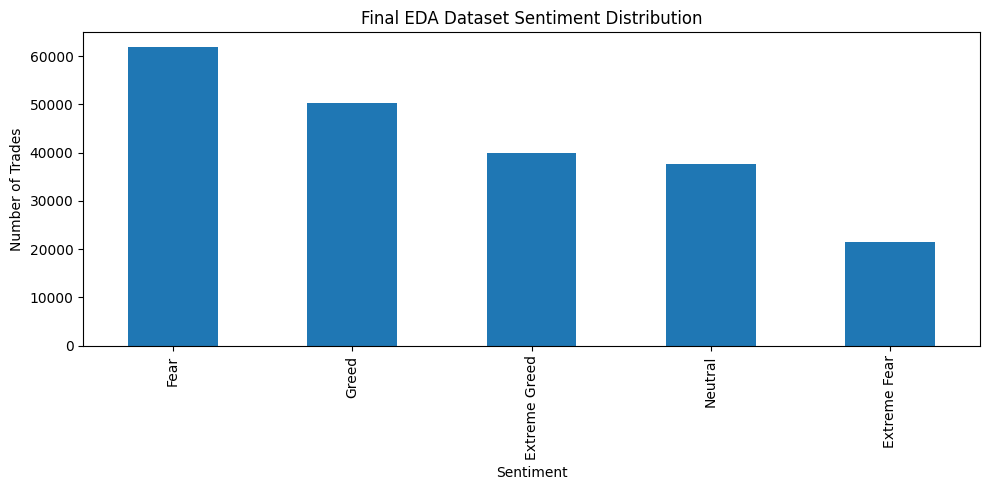


Final EDA dataset saved successfully.

Saved Path: /content/drive/MyDrive/Primetrade_Assignment/final_eda_dataset.csv


In [6]:
# ============================================================
# PHASE 2 - STEP 6:
# DATA CONSISTENCY CHECKS
# FINAL EDA DATASET CREATION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


def check_trading_data_consistency(dataframe):
    """
    Check for impossible values in trading dataset.
    """

    consistency_results = {
        "Negative Size USD":
            (dataframe["Size USD"] < 0).sum(),

        "Negative Size Tokens":
            (dataframe["Size Tokens"] < 0).sum(),

        "Negative Fee":
            (dataframe["Fee"] < 0).sum(),

        "Execution Price <= 0":
            (dataframe["Execution Price"] <= 0).sum(),

        "Missing Timestamp":
            dataframe["Timestamp IST"].isnull().sum(),

        "Missing Coin":
            dataframe["Coin"].isnull().sum(),

        "Missing Account":
            dataframe["Account"].isnull().sum()
    }

    return consistency_results


def check_sentiment_data_consistency(dataframe):
    """
    Check sentiment dataset consistency.
    """

    consistency_results = {
        "Score Below 0":
            (dataframe["value"] < 0).sum(),

        "Score Above 100":
            (dataframe["value"] > 100).sum(),

        "Missing Classification":
            dataframe["classification"].isnull().sum(),

        "Missing Date":
            dataframe["date"].isnull().sum()
    }

    return consistency_results


def create_final_eda_dataset(
    merged_dataframe
):
    """
    Create final EDA-ready dataset.
    """

    eda_dataframe = (
        merged_dataframe
        .dropna(
            subset=["classification"]
        )
        .copy()
    )

    return eda_dataframe


def get_final_dataset_summary(
    dataframe
):
    """
    Generate final dataset summary.
    """

    summary = {
        "Rows": len(dataframe),
        "Columns": len(dataframe.columns),
        "Unique Traders":
            dataframe["Account"].nunique(),

        "Unique Coins":
            dataframe["Coin"].nunique(),

        "Sentiment Categories":
            dataframe["classification"].nunique(),

        "Date Range Start":
            dataframe["Merge_Date"].min(),

        "Date Range End":
            dataframe["Merge_Date"].max()
    }

    return summary


def plot_sentiment_distribution(
    dataframe
):
    """
    Final sentiment distribution.
    """

    sentiment_counts = (
        dataframe["classification"]
        .value_counts()
    )

    plt.figure(figsize=(10, 5))

    sentiment_counts.plot(
        kind="bar"
    )

    plt.title(
        "Final EDA Dataset Sentiment Distribution"
    )

    plt.xlabel(
        "Sentiment"
    )

    plt.ylabel(
        "Number of Trades"
    )

    plt.tight_layout()

    plt.show()


def save_final_dataset(
    dataframe,
    output_path
):
    """
    Save final EDA-ready dataset.
    """

    dataframe.to_csv(
        output_path,
        index=False
    )


# ============================================================
# MAIN PROGRAM
# ============================================================

trading_consistency = (
    check_trading_data_consistency(
        historical_df
    )
)

sentiment_consistency = (
    check_sentiment_data_consistency(
        fear_greed_df
    )
)

final_eda_df = (
    create_final_eda_dataset(
        merged_df
    )
)

final_summary = (
    get_final_dataset_summary(
        final_eda_df
    )
)

# ============================================================
# OUTPUTS
# ============================================================

print("=" * 70)
print("TRADING DATA CONSISTENCY CHECKS")
print("=" * 70)

for key, value in trading_consistency.items():
    print(f"{key}: {value}")

print("\n")

print("=" * 70)
print("SENTIMENT DATA CONSISTENCY CHECKS")
print("=" * 70)

for key, value in sentiment_consistency.items():
    print(f"{key}: {value}")

print("\n")

print("=" * 70)
print("FINAL EDA DATASET SUMMARY")
print("=" * 70)

for key, value in final_summary.items():
    print(f"{key}: {value}")

print("\nFirst 5 Rows")

display(
    final_eda_df.head()
)

# ============================================================
# PLOT
# ============================================================

plot_sentiment_distribution(
    final_eda_df
)

# ============================================================
# SAVE FINAL DATASET
# ============================================================

final_dataset_path = (
    "/content/drive/MyDrive/"
    "Primetrade_Assignment/"
    "final_eda_dataset.csv"
)

save_final_dataset(
    final_eda_df,
    final_dataset_path
)

print("\nFinal EDA dataset saved successfully.")

print(
    "\nSaved Path:",
    final_dataset_path
)